
<div style="text-align: center; padding: 30px 10px;">

<h1 style="color:#ff7500; font-size: 24px; margin-bottom: 10px;">
МФТИ ФПМИ
</h1>

<h2 style="font-size: 30px; margin-top: 5px;">
Практикум Python - Продвинутый Поток
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

<h3 style="font-size: 36px;">
11. Requests. Парсинг. BeautifuSoup.
</h3>

<p style="margin-top: 20px;">
<strong>Дата:</strong> 07 апреля - 09 апреля 2026 года<br>
</p>

<p style="margin-top: 25px;">
Данный ноутбук является частью серии семинаров по курсу  
<em>«Практикум Python»</em> и предназначен для учебных и образовательных целей.
</p>

</div>

# Взаимодействие программ между собой. API.

## Определение API и пример

*API (Application programming interface)* — это контракт, который предоставляет программа. «Ко мне можно обращаться так и так, я обязуюсь делать то и это».


**Зачем это нужно?** Для того, чтобы при обращении к программе был определенный интерфейс, который регулировал, что и как выдаётся. Так будет проще и для программы, которая делает запрос (не надо будет искать по HTML, где лежит нужная информация) - и безопаснее для программы, формирующей ответ (случайно не утечет лишняя информация).

**Пример**

*Вариант 1.* Вы хотите позвонить в ресторан и зарезервировать столик на двоих на 20:00. Телефон снимает работник, смотрит по табличке резерваций и отвечает вам "Хорошо, ждём вас завтра в восемь".

По сути тут есть вы - пользователь, ресторан - программа, работник, снявший телефон - интерфейс API; звонок в ресторан - запрос, ответ работника - ответ на запрос.


*Вариант 2.* Вы звоните в ресторан, чтобы зарезервировать столик на двоих на 20:00, а вам в ответ присылают табличку со всеми резервациями на этот вечер с именами/фамилиями, телефонами и другой информацией.


*Вариант 3.* Вы звоните в ресторан, но сколько бы вы ни звонили, никто не снимает трубку :(

**Сравните эти варианты между собой. Какой лучше?**

## Структура запроса

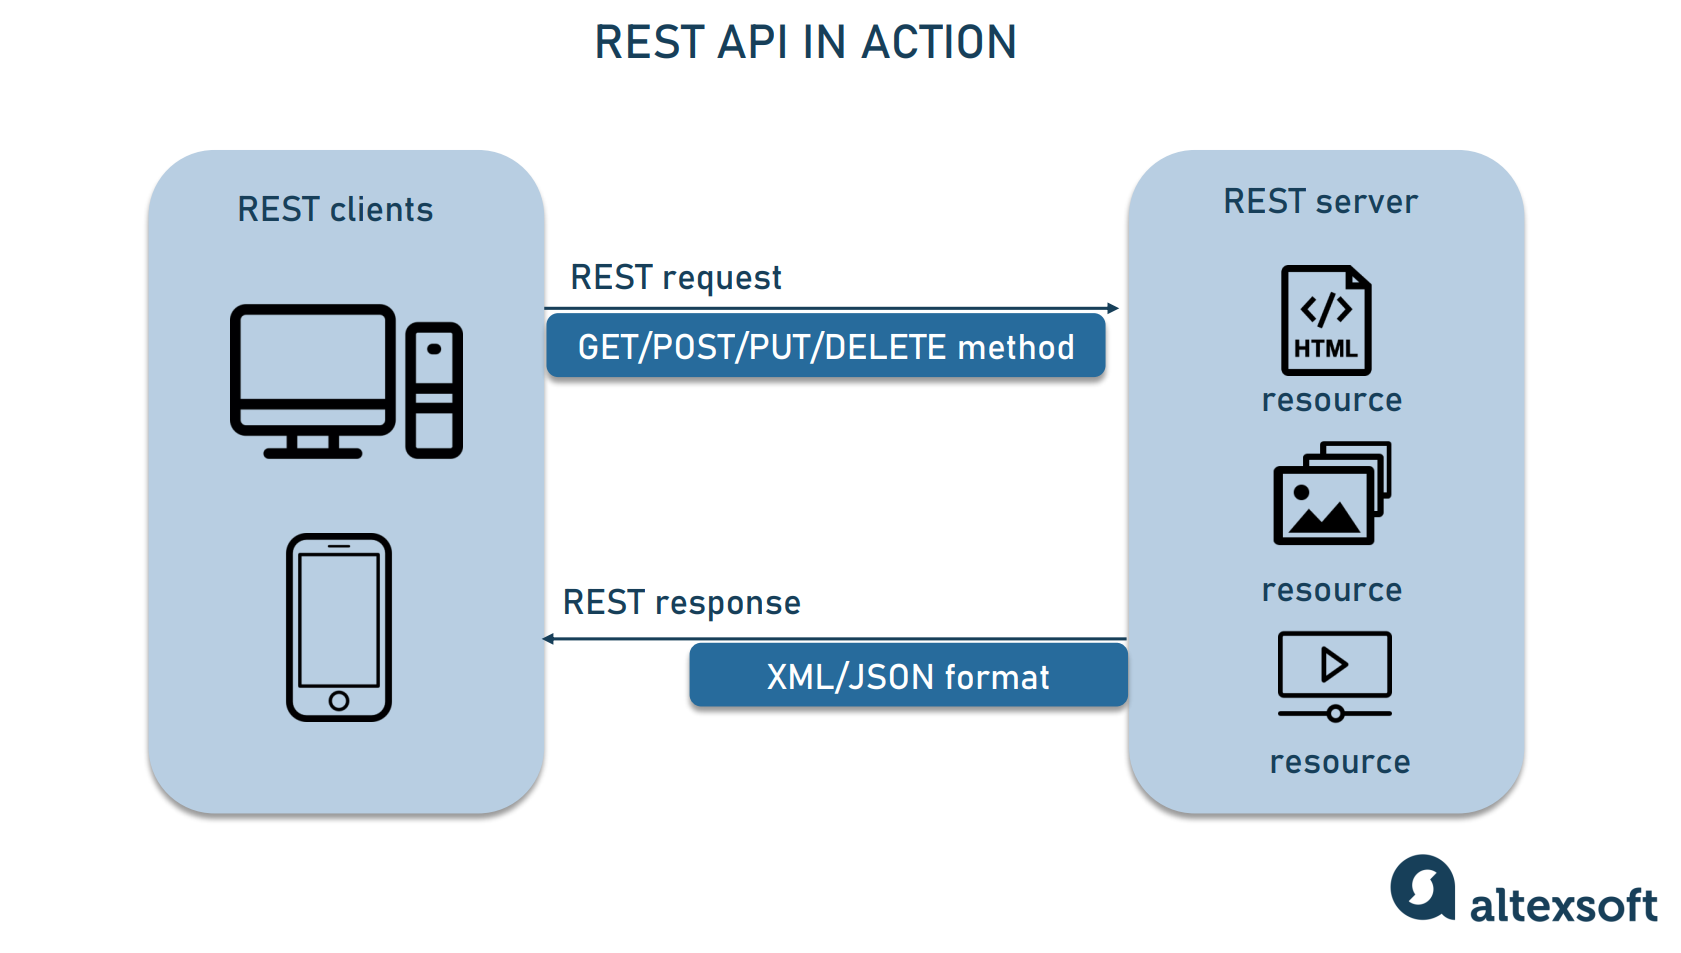

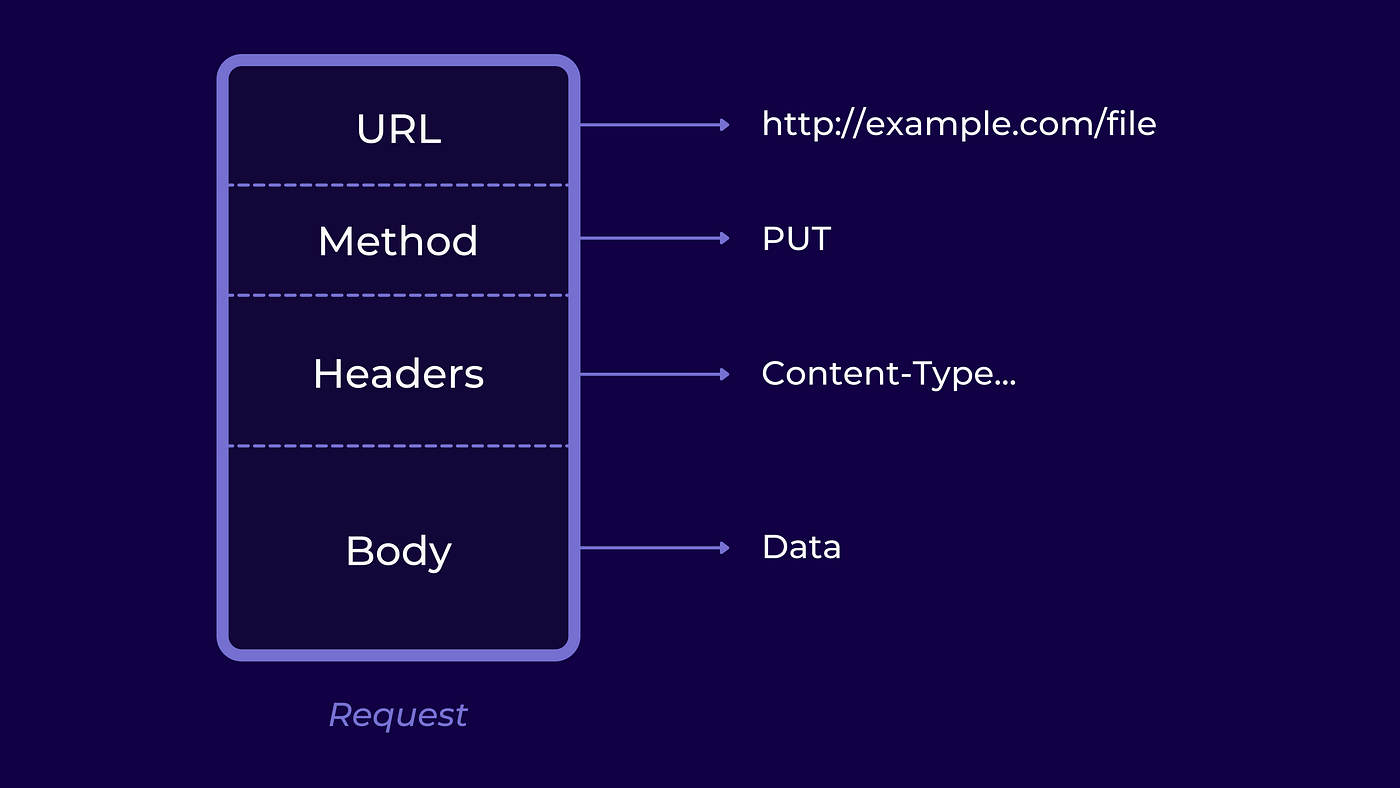

У запроса есть:

**URL** - ссылка, куда мы обращаемся

**Method** - метод, основные 4 варианта:
GET - получить информацию из сервиса
POST - добавить информацию на сервис
PUT - добавить/обновить информацию на сервисе
DELETE - удалить информацию с сервиса


**Headers** - заголовки, какая-то мета-информация о запросе, которая не связана с самим запросом.

Примеры: ключ для авторизации, формат возвращаемой информации (JSON/XML)

**Body** - параметры, непосредственно важные для запроса - на примере с рестораном, дата, когда хотим прийти, количество человек.

Часто в случае с GET запросами стараются не использовать Body непосредственно, а вместо этого "добавить" эти параметры в ссылку:



```
https://<ссылка>.ru/?date="2024-11-10"&people_amount=2
```



## JSON

**JSON (JavaScript Object Notation)** - формат файла, часто используемый при передаче данных по API. Он легко читается как машиной, так и человеком; суть - набор вложенных словарей и списков.

**Пример**:



```
{
    "glossary": {
        "title": "example glossary",
		"GlossDiv": {
            "title": "S",
			"GlossList": {
                "GlossEntry": {
                    "ID": "SGML",
					"SortAs": "SGML",
					"GlossTerm": "Standard Generalized Markup Language",
					"Acronym": "SGML",
					"Abbrev": "ISO 8879:1986",
					"GlossDef": {
                        "para": "A meta-markup language, used to create markup languages such as DocBook.",
						"GlossSeeAlso": ["GML", "XML"]
                    },
					"GlossSee": "markup"
                }
            }
        }
    }
}
```





Для работы с объектами JSON есть библиотечка JSON.

## Swagger

Система генерации документации к API. По документации легко можно понять, какие есть возможные методы для запросов и что они требуют на вход.

**Примеры документаций API:**


[Открытый API Банка Точка](https://enter.tochka.com/doc/v2/redoc/tag/Rabota-s-balansami-schetov#get_authorized_card_transactions_open_banking__apiVersion__accounts__accountId__authorized_card_transactions_get)

[API Яндекс Погоды](https://yandex.ru/dev/weather/doc/ru/concepts/parameters#temperature)

[Пример Swagger API](https://petstore.swagger.io/)


## Секреты в Google Colab

Если нам нужно сохранить что-то персональное (например, ключ для доступа к погоде), то это можно положить в секреты Google Colab. Это вкладка слева с ключом.

Код внизу показывает, как получить доступ к этим секретам

In [ ]:
from google.colab import userdata
yw_key = userdata.get('Yandex_weather')

## Пример кода для обращения к Яндекс.Погода

In [ ]:
import requests

headers = {
    'X-Yandex-Weather-Key': yw_key
}

# Координаты КПМ в г. Долгопрудный
lat = '55.92916'
lon = '37.52142'

response = requests.get(f'https://api.weather.yandex.ru/v2/forecast?lat={lat}&lon={lon}', headers=headers)

response.json()

In [ ]:
import json

x = json.loads(response.text)
x

In [ ]:
# Получили то же самое - некий dict, а в нём значения и массивы

x['forecasts']

In [ ]:
x['forecasts'][0] # прогноз до конца этого дня

In [ ]:
x['forecasts'][0]['hours'] # почасовая погода на сегодня

In [ ]:
x['forecasts'][0]['hours'][19] # погода сегодня в 8 вечера

# Selenium

# Quick Recap

Веб-скреппинг = скачивание данных (сохряняем файлик) + парсинг данных (выделяем полезные данные)

**Скачивание данных:**
- curl
- socket
- **requests**

**Парсинг данных:**
- регулярки
- lxml
- **BeautifulSoup**

**Проблема** - современный Web намного сложнее обычного html-файла, который скачиваем!

Современный сайт по сути - это отдельное приложение, которое видоизменяется без явного запроса новых данных.

В таких случаях простое скачивание html-страницы может быть недостаточным

**Пример** - веб-приложение на Vue.js (один из популярных фреймворков): https://quasar-company-profile-template.netlify.app/#/

Попробуем его распарсить:

In [ ]:
import requests


vue_js_example = "https://quasar-company-profile-template.netlify.app/#/"
response = requests.get(vue_js_example)
html = response.text
print(html)

<!DOCTYPE html><html><head><title>Company Profile Website Using Quasar</title><meta charset=utf-8><meta name=description content="Free template for office website."><meta name=format-detection content="telephone=no"><meta name=msapplication-tap-highlight content=no><meta name=viewport content="user-scalable=no,initial-scale=1,maximum-scale=1,minimum-scale=1,width=device-width"><link rel=icon type=image/png href=statics/app-logo-128x128.png><link rel=icon type=image/png sizes=16x16 href=statics/icons/favicon-16x16.png><link rel=icon type=image/png sizes=32x32 href=statics/icons/favicon-32x32.png><link rel=icon type=image/png sizes=96x96 href=statics/icons/favicon-96x96.png><link rel=icon type=image/ico href=statics/icons/favicon.ico><link href=css/3.56c39bc2.css rel=prefetch><link href=js/3.bc57053d.js rel=prefetch><link href=js/4.324290a5.js rel=prefetch><link href=css/app.488485fd.css rel=preload as=style><link href=js/app.ebcd94bb.js rel=preload as=script><link href=js/runtime.0ad210

Чрезвычайно читаемо... Разработчики борятся за каждый байт и сэкономили на пробелах :(

Проверим, где здесь лежит тег `span` - в одном из них должна быть информация о ценах:

In [ ]:
!pip3 install lxml beautifulsoup4
!mamba install -c anaconda lxml -y

In [ ]:
import lxml

In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, 'lxml')
spans = soup.find_all('span')

print(spans)

[]


Ничего нет! А где же наши данные? Они же есть на сайте!

Они подгружаются не сразу, а при необходимости скриптом - с помощью `requests` такое не загрузить так просто...

Не прибегая к другим инструментам, нам придется копаться в исходном коде скриптов на JS, смотреть какие запросы сайт делает - одним словом боль!

А что если нам просто запустить с помощью Python браузер, раз с его помощью все корректно запускается, и получать данные как-нибудь из него? Этим и занимается Selenium!

# Selenium

Установим Selenium:

In [ ]:
!pip install --upgrade selenium

Установим менеджер движков браузера (облегчит работу):

In [ ]:
!pip install --upgrade webdriver_manager

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# Подключим движок браузера, если его нет, то сначала установим
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

driver.get("https://www.google.com/")

gУра! Ячейка отработала, браузер запустился и перешел на нужную страничку! Теперь можем делать с ним всякие штуки!

Но для начала перейдем на нашу проблемную страницу:

In [ ]:
driver.get(vue_js_example)

Попробуем получить наши желанные `span`-ы:

In [ ]:
from selenium.webdriver.common.by import By

spans = driver.find_elements(By.TAG_NAME, "span")
print(len(spans))

29


Супер! Давайте посмотрим на первый из них:

In [ ]:
print(spans[0])

<selenium.webdriver.remote.webelement.WebElement (session="e1fad03cb864de451c720f29f6c229dd", element="252056CED30531FE6923E41817FC9FAE_element_50")>


Не слишком информативно... Попробуем ткнуться в какой-нибудь атрибут:

In [ ]:
spans[0].text

'Kudos'

Отлично, получили что-то полезное! Давайте конкретизируем наш запрос, указав класс нашего тега `span`:

In [ ]:
spans = driver.find_elements(By.CSS_SELECTOR, "span.text-h2.text-center")
print(len(spans))

4


Еще ближе, посмотрим содержимое:

In [ ]:
[item.text for item in spans]

['$0', '$50', '$250', '$500']

Победа!

Но пока пример скучный - мы лишь один раз загрузили страничку. Как еще мы можем поработать с сайтом динамично (как человек)?

## Пример №2

Попробуем скачать новости с главной страницы Вышки:

In [ ]:
driver = webdriver.Chrome(service=service)

In [ ]:
driver.get("https://www.hse.ru/")

In [ ]:
lang = driver.find_element(By.CSS_SELECTOR, "div.main-lang__control")
lang

<selenium.webdriver.remote.webelement.WebElement (session="7d5323ca8b9ca2a8dbb5a2010e7a0832", element="19C0D7E61D5295E1FB10B6C4E06BE5B1_element_788")>

In [ ]:
lang.click()

In [ ]:
ru_lang = [item for item in driver.find_elements(By.CSS_SELECTOR, "li.main-lang__item") if item.text == "RU"][0]
ru_lang

<selenium.webdriver.remote.webelement.WebElement (session="7d5323ca8b9ca2a8dbb5a2010e7a0832", element="19C0D7E61D5295E1FB10B6C4E06BE5B1_element_753")>

In [ ]:
ru_lang.click()

Странно, почему-то выдалась информация на английском...

Покопавшись, найдем, что проблема - в cookie с именем `_lang`. Добавим печеньку и запросим сайт еще раз:

In [ ]:
driver.add_cookie({"name": '_lang', "value": '%2F%2Fwww.hse.ru%2F'})
driver.get("https://www.hse.ru/")

In [ ]:
driver.get_cookies()

Отлично! Теперь получим элементы отдельных новостей:

In [ ]:
news_block = driver.find_element(By.CLASS_NAME, 'main-news')
news_block

<selenium.webdriver.remote.webelement.WebElement (session="7d5323ca8b9ca2a8dbb5a2010e7a0832", element="125E614C2BB732FDDD41554970BB092F_element_5912")>

In [ ]:
news_title_elements = news_block.find_elements(By.CLASS_NAME, "main-news-card__title")
news_titles = [item.text for item in news_title_elements]
news_titles

['«Проектная школа»: в Вышке стартовал новый образовательный проект для учителей',
 '«Социология живет, если она востребована обществом»',
 'Красные линии: эксперты обсудили вопросы этики и права в сфере ИИ',
 'Открытые вебинары «Вышки Онлайн»: от доходности криптовалют до ассортативности браков по уровню образования',
 '«Мы вернулись к той ценностной парадигме, когда ученый — это достойная, престижная, оплачиваемая профессия»',
 'В Нижнем Новгороде завершился региональный этап кейс-чемпионата по экономике и предпринимательству',
 '«Для НИУ ВШЭ важно укреплять позиции российского образования и науки»',
 '«Теперь нам с этим жить»: как прорывные технологии меняют образование',
 'Команда МИЭМ ВШЭ вошла в число призеров чемпионата «Интегрируй!»']

Получили элементы с заголовками новостей. Теперь нужно пройтись по ним и собрать полный текст новостей:

In [ ]:
news = dict()
for title, element in zip(news_titles, news_title_elements):
    element.find_element(By.TAG_NAME, "a").click()
    text_element = driver.find_element(By.CLASS_NAME, "post__text")
    news[title] = text_element.text
    print(title)
    driver.back()

Странно, вроде все верно, но почему-то ошибка...

При перезагрузке страницы пересоздаются и ее элементы, поэтому вернувшись на главную страницу кликнуть по следующей новости мы не сможем!

Нужно каждый раз получать? Есть обходной вариант - сохраним ссылки, а затем пройдем по ним:

In [ ]:
news_block = driver.find_element(By.CLASS_NAME, 'main-news')
news_title_elements = news_block.find_elements(By.CLASS_NAME, "main-news-card__title")
news_title_links = [item.find_element(By.TAG_NAME, "a").get_attribute("href") for item in news_title_elements]
print(news_title_links)

['https://www.hse.ru/news/edu/873567977.html', 'https://www.hse.ru/news/edu/873545467.html', 'https://www.hse.ru/news/expertise/873530215.html', 'https://www.hse.ru/news/edu/873540366.html', 'https://www.hse.ru/news/communication/873534830.html', 'https://www.hse.ru/news/edu/873522323.html', 'https://www.hse.ru/news/life/873322492.html', 'https://www.hse.ru/news/edu/873343069.html', 'https://www.hse.ru/news/life/873354510.html']


In [ ]:
news = dict()
for title, url in zip(news_titles, news_title_links):
    driver.get(url)
    text_element = driver.find_element(By.CLASS_NAME, "post__text")
    news[title] = text_element.text
    print(title)

«Проектная школа»: в Вышке стартовал новый образовательный проект для учителей
«Социология живет, если она востребована обществом»
Красные линии: эксперты обсудили вопросы этики и права в сфере ИИ
Открытые вебинары «Вышки Онлайн»: от доходности криптовалют до ассортативности браков по уровню образования
«Мы вернулись к той ценностной парадигме, когда ученый — это достойная, престижная, оплачиваемая профессия»
В Нижнем Новгороде завершился региональный этап кейс-чемпионата по экономике и предпринимательству
«Для НИУ ВШЭ важно укреплять позиции российского образования и науки»
«Теперь нам с этим жить»: как прорывные технологии меняют образование
Команда МИЭМ ВШЭ вошла в число призеров чемпионата «Интегрируй!»


In [ ]:
news['В Нижнем Новгороде завершился региональный этап кейс-чемпионата по экономике и предпринимательству']

'Нижегородский кампус НИУ ВШЭ выступил организатором регионального этапа Всероссийского кейс-чемпионата по экономике и предпринимательству. Участниками стали более 120 старшеклассников в составе 40 команд из Ярославля, Кирова, Калуги, Коряжмы, Нижнего Новгорода и других городов.\nПресс-служба НИУ ВШЭ — Нижний Новгород.\nКейс-чемпионат школьников по экономике и предпринимательству − это состязание, в котором команды участников при поддержке менторов решают реальные бизнес-задачи, разрабатывают собственные проекты и получают профессиональную оценку экспертов от бизнес-структур, вузов и органов власти.\nПресс-служба НИУ ВШЭ — Нижний Новгород\nТрадиционно Всероссийский кейс-чемпионат по экономике и предпринимательству проводится по двум направлениям: кейс-направление выявляет способность участников анализировать и самостоятельно принимать решения в реальных ситуациях, участники бизнес-направления готовят бизнес-решение с описанием и прогнозом по реализации проекта. \nРегиональный кейс-чемп

Победа!

## Третий пример - парсинг цен Окей

Попробуем собрать данные по ценам из онлайн-каталога магазина Окей:

Рассмотрим еще один пример - парсинг цен продуктов магазина Окей:

In [ ]:
driver.get("https://www.okeydostavka.ru/msk")

Получили ошибку 403 - Доступ закрыт. Как так?

Владельцы сайта не хотят, чтобы всякие скрипты просматривали их сайт :(

**Вариант обхода - изменить User-Agent!**

Сейчас мы явно говорим сайту, что мы - браузер под управлением Selenium. А что если мы представимся по-другому?

Для этого нужно перезапустить наш браузер с новыми параметрами:

In [ ]:
driver.close()

In [ ]:
!pip install undetected-chromedriver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 345.6 kB/s eta 0:00:0031m1.2 MB/s eta 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for undetected-chromedriver: filename=undetected_chromedriver-3.5.4-py3-none-any.whl size=47055 sha256=49397175b1aab79ff3c80a78ae8575e06568f2f0fff79495663ab88f50ba2546
  Stored in directory: /home/nick/.cache/pip/wheels/0c/a6/72/5c948853baf75d52f1da173bd8fc9d7ad7615608e0ffaead6d
Successfully built undetected-chromedriver


In [ ]:
import undetected_chromedriver as uc

service = Service(ChromeDriverManager().install())
driver = uc.Chrome(service=service)

# driver.execute_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")
driver.get("https://www.okeydostavka.ru/msk")

Для простоты будем собирать цены только в одной категории товаров - "Творожные изделия":

In [ ]:
driver.get("https://www.okeydostavka.ru/msk/molochnye-produkty-syry-iaitso/molochnye-produkty/tvorozhnye-izdeliia")

Заметим, что вылезает значок загрузки, поэтому добавим дополнительную команду для ожидания:

In [ ]:
from time import sleep

In [ ]:
products = driver.find_elements(By.CSS_SELECTOR, "div.product.ok-theme ")
len(products)

150

In [ ]:
product_data = []
for product in products[:]:
    product_name = product.find_element(By.CSS_SELECTOR, "div.product-name").find_element(By.TAG_NAME, "a").get_attribute("title")
    product_price = product.find_element(By.CSS_SELECTOR, "div.product-price").find_element(By.TAG_NAME, "span").get_attribute("innerHTML").strip()
    print(product_name, product_price)

Творог Простоквашино 5% 200г БЗМЖ 119,49 ₽
Творог Простоквашино мягкий 5% 130г БЗМЖ 41,99 ₽
Сырок глазированный Ростагроэкспорт ваниль 20% 45г БЗМЖ 28,59 ₽
Сырок глазированный Ростагроэкспорт сгущенное молоко 15% 45г БЗМЖ 28,59 ₽
Сырок творожный глазированный А.Ростагрокомплекс ваниль в молочном шоколаде 26% 50г БЗМЖ 69,49 ₽
Творог Простоквашино 2% 200г БЗМЖ 94,99 ₽
Творог мягкий Савушкин продукт 5% 125г БЗМЖ 42,39 ₽
Сырок глазированный Ростагроэкспорт ваниль 5% 45г БЗМЖ 30,59 ₽
Сырок глазированный Ростагроэкспорт Картошка 20% 50г БЗМЖ 30,49 ₽
Сырок творожный глазированный А.Ростагрокомплекс сгущенка в молочном шоколаде 50г БЗМЖ 69,49 ₽
Сырок глазированный О`КЕЙ 25% ваниль 40г БЗМЖ 23,99 ₽
Сырок глазированный Свитлогорье ваниль 26% 50г БЗМЖ 48,49 ₽
Сырок творожный глазированный А.Ростагрокомплекс в темном шоколаде с ванилью 26% 50г БЗМЖ 69,49 ₽
Сырок творожный глазированный Вкуснотеево вареная сгущенка 23% 40г БЗМЖ 19,99 ₽
Сырок творожный глазированный Вкуснотеево ваниль 23% 40г БЗМЖ 2

Названия неполные и цены без учета скидок!